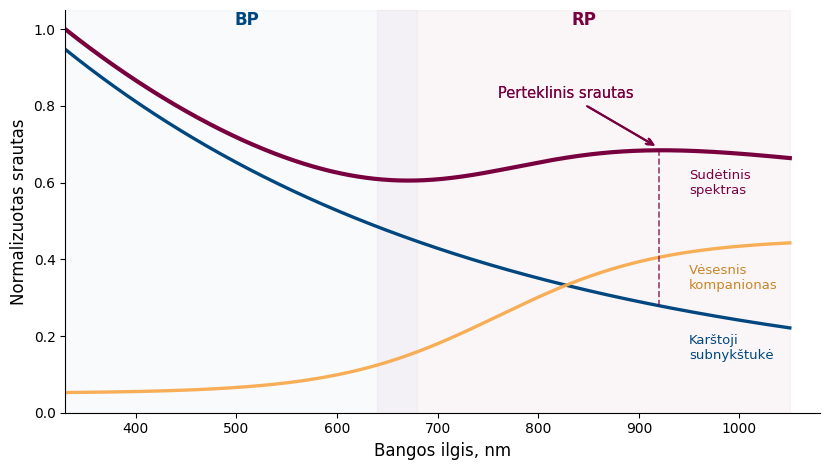

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Spalvos
# ==========================================

VUBurgundy = "#78003F"
VUBlue = "#6193CD"
VUYellow = "#F7AA4E"
MIFBlue = "#00477F"

# ==========================================
# Bangos ilgiai
# ==========================================

wl = np.linspace(330, 1050, 600)

# ==========================================
# Scheminiai spektrai
# ==========================================

sdB = 1.15 * np.exp(-(wl - 330) / 420) + 0.08
companion = 0.12 + 0.95 / (1 + np.exp(-(wl - 760) / 80))
combined = sdB + 0.55 * companion

# Normalizavimas
sdB = sdB / combined.max()
companion = 0.55 * companion / combined.max()
combined = combined / combined.max()

# ==========================================
# Figure
# ==========================================

fig, ax = plt.subplots(figsize=(8.4, 4.8))

# BP / RP fonas
ax.axvspan(330, 680, color=VUBlue, alpha=0.045)
ax.axvspan(640, 1050, color=VUBurgundy, alpha=0.035)

# Kreivės
ax.plot(
    wl,
    sdB,
    color=MIFBlue,
    linewidth=2.4,
)

ax.plot(
    wl,
    companion,
    color=VUYellow,
    linewidth=2.4,
    alpha=0.95,
)

ax.plot(
    wl,
    combined,
    color=VUBurgundy,
    linewidth=3.0,
)

# ==========================================
# Minimalūs BP / RP užrašai
# ==========================================

ax.text(
    510,
    1.01,
    "BP",
    color=MIFBlue,
    fontsize=12,
    fontweight="bold",
    ha="center"
)

ax.text(
    845,
    1.01,
    "RP",
    color=VUBurgundy,
    fontsize=12,
    fontweight="bold",
    ha="center"
)

# ==========================================
# Annotation
# ==========================================

ax.annotate(
    "Perteklinis srautas",
    xy=(920, 0.69),
    xytext=(760, 0.82),
    fontsize=10.5,
    color=VUBurgundy,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color=VUBurgundy,
        shrinkA=3,
        shrinkB=3
    )
)

# ==========================================
# Ašys
# ==========================================

ax.set_xlabel(
    "Bangos ilgis, nm",
    fontsize=12
)

ax.set_ylabel(
    "Normalizuotas srautas",
    fontsize=12
)

ax.set_xlim(330, 1050)
ax.set_ylim(0, 1.05)
# ==========================================
# Dotted line grąžinam
# ==========================================

x_mark = 920

y_comb = combined[np.argmin(np.abs(wl - x_mark))]
y_sdb = sdB[np.argmin(np.abs(wl - x_mark))]

ax.vlines(
    x_mark,
    y_sdb,
    y_comb,
    color=VUBurgundy,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75
)

# ==========================================
# Annotation pataisytas
# ==========================================

ax.annotate(
    "Perteklinis srautas",
    xy=(920, 0.69),
    xytext=(760, 0.82),
    fontsize=10.5,
    color=VUBurgundy,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5,
        color=VUBurgundy,
        shrinkA=4,
        shrinkB=4
    )
)

# ==========================================
# Inline labels perstumti
# ==========================================

ax.text(
    950,
    0.6,
    "Sudėtinis\nspektras",
    color=VUBurgundy,
    fontsize=9.5,
    ha="left",
    va="center"
)

ax.text(
    950,
    0.35,
    "Vėsesnis\nkompanionas",
    color="#C98527",
    fontsize=9.5,
    ha="left",
    va="center"
)

ax.text(
    950,
    0.17,
    "Karštoji\nsubnykštukė",
    color=MIFBlue,
    fontsize=9.5,
    ha="left",
    va="center"
)

# ==========================================
# Daugiau vietos dešinėje
# ==========================================

ax.set_xlim(330, 1080)

# ==========================================
# Stilius
# ==========================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()

# ==========================================
# Export
# ==========================================

plt.savefig(
    "sdb_rp_excess_clean.svg",
    format="svg",
    bbox_inches="tight"
)

plt.savefig(
    "sdb_rp_excess_clean.png",
    dpi=300,
    bbox_inches="tight"
      )

plt.show()